# Práctica 4. Procesamiento audio - Identificador de notas musicales

## Importación de librerías

In [14]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import find_peaks
from scipy.fft import fft, fftfreq


## Implementación de clases y funciones

### AudioProcessor
A continuación, se define la clase `AudioProcessor`, encargada de procesar archivos de audio y analizar su contenido en el dominio de las frecuencias.

Esta clase tiene tres métodos principales:
1. `load audio()`: Lee los datos de audio a partir de un archivo `.wav`. Si el archivo tiene varios canales, lo convierte a uno solo promediando los canales. Luego, convierte los datos a tipo `float` y los normaliza en un rango entre -1 y 1. Finalmente, devuelve la cantidad de muestras por segundo (`sample_rate`) y los valores de la señal (`audio_data`).
2. `extract_fundamental_frequencies()`: Analiza el audio para identificar las frecuencias principales del sonido. Para ello, usa la **Transformada Rápida de Fourier (FFT)**, que descompone el sonido en sus diferentes frecuencias. Después, busca los picos más altos en el espectro (las frecuencias más fuertes) y los analiza para quedarse con la frecuencia base, descartando los armónicos. Devuelve una lista con las frecuencias detectadas y su intensidad.
3. `visualize_spectrum()`: Muestra un gráfico con el espectro de frecuencias del audio. En el eje X se representan las frecuencias (en Hz) y en el eje Y, la magnitud de cada frecuencia.

In [ ]:
class AudioProcessor:
    def __init__(self):
        pass

    def load_audio(self, filepath):
        sample_rate, audio_data = wavfile.read(filepath)
        if hasattr(audio_data, "shape") and len(audio_data.shape) > 1: # multicanal -> mono
            audio_data = np.mean(audio_data, axis=1) # promediado
        audio_data = audio_data.astype(float)
        maxabs = np.max(np.abs(audio_data)) if audio_data.size else 0.0
        if maxabs > 0:
            audio_data = audio_data / maxabs # normalización [-1.0, 1.0]
        return sample_rate, audio_data

    def extract_fundamental_frequencies(self, audio_data, sample_rate, 
                                        min_freq=30, max_freq=5000, num_peaks=5):
        n = len(audio_data)
        if n == 0:
            return []

        fft_values = fft(audio_data)
        fft_magnitude = np.abs(fft_values[:n//2])
        frequencies = fftfreq(n, 1/sample_rate)[:n//2]

        mask = (frequencies >= min_freq) & (frequencies <= max_freq)
        fft_magnitude = fft_magnitude[mask]
        frequencies = frequencies[mask]
        if frequencies.size == 0:
            return []

        threshold = np.max(fft_magnitude) * 0.02 # valores < threshold -> ruido

        peaks, properties = find_peaks(fft_magnitude,
                                       height=threshold,
                                       distance=15,
                                       prominence=threshold * 0.2)
        if len(peaks) == 0:
            return []

        peak_indices = np.argsort(properties['peak_heights'])[::-1]
        top_peaks = peaks[peak_indices[:num_peaks * 5]]

        detected_freqs = frequencies[top_peaks]
        detected_mags  = fft_magnitude[top_peaks]

        fundamental_candidates = []

        for freq, mag in zip(detected_freqs, detected_mags):
            is_fundamental = True
            subharmonic_penalty = 0.0

            # ¿freq es un armónico de una nota más grave?
            for other_freq in detected_freqs:
                if other_freq < freq * 0.8:
                    ratio = freq / other_freq
                    if abs(ratio - round(ratio)) < 0.1:
                        is_fundamental = False
                        subharmonic_penalty = ratio
                        break
            # ¿freq tiene armónicos?
            if is_fundamental:
                harmonic_score = 0
                for other_freq in detected_freqs:
                    if other_freq > freq * 1.85 and other_freq < freq * 8.5: # rango de armónicos
                        ratio = other_freq / freq
                        if abs(ratio - round(ratio)) < 0.1:
                            harmonic_score += 1

                # pesos: favorece las frecuencias bajas
                boost = 1.0
                if freq < 80: boost = 5.0
                elif freq < 120: boost = 4.0
                elif freq < 200: boost = 2.5
                elif freq < 300: boost = 1.5
                elif freq > 4000: boost = 0.3
                elif freq > 3000: boost = 0.6

                harmonic_boost = 1 + (harmonic_score * 0.8)
                adjusted_mag = mag * boost * harmonic_boost
                fundamental_candidates.append((freq, adjusted_mag, mag))
            else:
                # freq parece un armónico
                if freq < 100 and subharmonic_penalty > 1:
                    penalized_mag = mag * 0.1
                    fundamental_candidates.append((freq, penalized_mag, mag))

        # si no se han detectado fundamentales, se devuelven los picos más altos
        if not fundamental_candidates:
            for f, m in zip(detected_freqs[:num_peaks], detected_mags[:num_peaks]):
                fundamental_candidates.append((f, m, m))

        # ordenar por magnitud ajustada
        fundamental_candidates.sort(key=lambda x: x[1], reverse=True)
        final_candidates = fundamental_candidates[:num_peaks * 2]

        unique = {}
        for freq, adj_mag, orig_mag in final_candidates:
            if freq not in unique or adj_mag > unique[freq][1]:
                unique[freq] = (freq, adj_mag, orig_mag)

        result = [(f, orig) for (f, _, orig) in sorted(unique.values(), key=lambda x: x[1], reverse=True)]
        return result[:num_peaks]

    def visualize_spectrum(self, audio_data, sample_rate, notes_detected):
        n = len(audio_data)
        fft_values = fft(audio_data)
        fft_magnitude = np.abs(fft_values[:n//2])
        frequencies = fftfreq(n, 1/sample_rate)[:n//2]

        mask = frequencies < 2000
        plt.plot(frequencies[mask], fft_magnitude[mask])

        for note, freq, mag in notes_detected[:5]:
            plt.axvline(x=freq, linestyle='--', alpha=0.7)
            plt.text(freq, mag, f'{note}\n{freq:.1f}Hz',
                     rotation=45, verticalalignment='bottom')

        plt.xlabel('Frecuencia (Hz)')
        plt.ylabel('Magnitud')
        plt.title('Espectro de Frecuencias')
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()


### NoteConverter
A continuación, se define la clase `NoteConverter`, encargada de convertir una frecuencia (en Hz) en una nota musical reconocible con su nombre en español. 

Esta clase tiene dos métodos principales:
- `build_table()`: Crea una tabla de referencia que relaciona cada nota (Do, Re, Mi, etc.) y su octava con la frecuencia correspondiente en Hz. Lo hace usando la afinación estándar, donde la nota La4 equivale a 440 Hz.
- `frequency_to_note()`: Dada una frecuencia cualquiera, busca en la tabla la nota más cercana en función de su diferencia en semitonos. Si la frecuencia está dentro de una cierta tolerancia, devuelve el nombre de la nota y su octava.

In [ ]:
class NoteConverter:
    def __init__(self):
        self.note_frequencies = None
        self.build_table()

    def build_table(self):
        if self.note_frequencies is not None:
            return
        notes = ['Do', 'Do#', 'Re', 'Re#', 'Mi', 'Fa', 'Fa#', 'Sol', 'Sol#', 'La', 'La#', 'Si']
        freqs = {}
        for octave in range(0, 9):
            for i, note in enumerate(notes):
                freq = 440.0 * (2 ** ((octave * 12 + i - 57) / 12.0))
                freqs[f'{note}{octave}'] = freq
        self.note_frequencies = freqs

    def frequency_to_note(self, frequency, tolerance=2.0):
        if frequency <= 0:
            return None
        min_diff = float('inf')
        closest_note = None

        for note, fref in self.note_frequencies.items():
            diff = abs(frequency - fref)
            if fref <= 0:
                continue
            cents = 1200 * np.log2(frequency / fref)
            if abs(cents) < tolerance * 100: # diferencia de `tolerance` semitonos
                if diff < min_diff:
                    min_diff = diff
                    closest_note = note
        return closest_note

### SingleNoteIdentifier
A continuación, se define la clase `SingleNoteIdentifier`, que permite identificar la nota musical que se escucha en un archivo de audio. Para ello, utiliza las funcionalidades de las clases definidas anteriormente, `AudioProcessor` y `NoteConverter`.

Esta clase tiene cinco métodos principales:
- `identify_note()`: Detecta la nota principal de un archivo de audio. Primero, extrae las frecuencias fundamentales usando `AudioProcessor`, y luego las convierte en notas con `NoteConverter`. Si se indica el parámetro `visualize=True`, también muestra el espectro de frecuencias en un gráfico. Devuelve la nota principal detectada, su frecuencia correspondiente y una lista con las demás notas que se encontraron.
- `extract_expected_note()`: Obtiene la nota esperada a partir del nombre del archivo. Devuelve la nota completa con octava, el nombre de la nota y el número de octava por separado.
- `extract_instrument()`: Obtiene el instrumento que interpreta la nota a partir del nombre del archivo. Si no se reconoce, devuelve "Desconocido".
- `batch_process_directory()`: Permite procesar una carpeta completa de archivos de audio de una sola vez. Para cada archivo `.wav`, detecta la nota, obtiene la esperada según el nombre del archivo y compara ambos resultados. Guarda toda la información (nota detectada, nota esperada, octava, instrumento, etc.) en una lista de resultados.
- `evaluate_accuracy()`: Calcula y muestra estadísticas de precisión del sistema, indicando cuántas notas fueron detectadas correctamente y mostrando ejemplos de errores para facilitar el análisis.

In [ ]:

class SingleNoteIdentifier:
    def __init__(self):
        self.audio = AudioProcessor()
        self.converter = NoteConverter()

    def identify_note(self, filepath, visualize=False):
        sample_rate, audio_data = self.audio.load_audio(filepath)
        detected_freqs = self.audio.extract_fundamental_frequencies(audio_data, sample_rate)

        if not detected_freqs:
            return None, None, []

        notes_detected = []
        for freq, magnitude in detected_freqs:
            note = self.converter.frequency_to_note(freq)
            if note:
                notes_detected.append((note, freq, magnitude))

        if not notes_detected:
            return None, None, []

        main_note = notes_detected[0][0]
        main_freq = notes_detected[0][1]

        if visualize:
            self.audio.visualize_spectrum(audio_data, sample_rate, notes_detected)

        return main_note, main_freq, notes_detected

    def extract_expected_note(self, filename):
        note_mapping = {
            'C': 'Do', 'C#': 'Do#', 'Db': 'Reb',
            'D': 'Re', 'D#': 'Re#', 'Eb': 'Mib',
            'E': 'Mi',
            'F': 'Fa', 'F#': 'Fa#', 'Gb': 'Solb',
            'G': 'Sol', 'G#': 'Sol#', 'Ab': 'Lab',
            'A': 'La', 'A#': 'La#', 'Bb': 'Sib',
            'B': 'Si'
        }
        pattern = r'([A-G][b#]?)(\d)'
        match = re.search(pattern, filename)
        if match:
            note_eng = match.group(1)
            octave = match.group(2)
            note_esp = note_mapping.get(note_eng, note_eng)
            return f"{note_esp}{octave}", note_esp, octave
        return None, None, None

    def extract_instrument(self, filepath):
        filename = os.path.basename(filepath).lower()
        inst_mapping = {
            'btb': 'Tuba Bajo',
            'hn': 'Trompa',
            'tbn': 'Trombón',
            'tpc': 'Trompeta en Do',
            'acc': 'Acordeón',
            'cb': 'Contrabajo',
            'vn': 'Violín',
            'va': 'Viola',
            'vc': 'Violonchelo',
            'bn': 'Fagot',
            'clbb': 'Clarinete en Sib',
            'fl': 'Flauta',
            'ob': 'Oboe',
            'asax': 'Saxofón alto'
        }
        for code, instrument_name in inst_mapping.items():
            if filename.startswith(code):
                return instrument_name
        return 'Desconocido'

    def batch_process_directory(self, directory_path):
        results = []
        for root, _, files in os.walk(directory_path):
            for file in files:
                if not file.lower().endswith('.wav'):
                    continue
                filepath = os.path.join(root, file)
                try:
                    note, freq, all_notes = self.identify_note(filepath)
                    instrument = self.extract_instrument(filepath)
                    expected_note_octave, expected_note, expected_octave = self.extract_expected_note(file)

                    note_name = note[:-1] if note else None
                    octave = note[-1] if note else None

                    note_correct = (note_name == expected_note) if (note_name and expected_note) else False
                    octave_correct = (octave == expected_octave) if (octave and expected_octave) else False
                    both_correct = note_correct and octave_correct

                    results.append({
                        'file': file,
                        'instrument': instrument,
                        'main_note': note,
                        'note_name': note_name,
                        'octave': octave,
                        'frequency': freq,
                        'all_notes': [n[0] for n in all_notes[:3]],
                        'expected_note_octave': expected_note_octave,
                        'expected_note': expected_note,
                        'expected_octave': expected_octave,
                        'note_correct': note_correct,
                        'octave_correct': octave_correct,
                        'both_correct': both_correct
                    })
                except Exception as e:
                    print(f"Error procesando {file}: {str(e)}")
        return results
    
    def evaluate_accuracy(self, results):
        total = len(results)
        identified = sum(1 for r in results if r['main_note'] is not None)

        expected_results = [r for r in results if r.get('expected_note_octave')]
        total_expected_results = len(expected_results)

        if total_expected_results > 0:
            note_correct = sum(1 for r in expected_results if r.get('note_correct', False))
            octave_correct = sum(1 for r in expected_results if r.get('octave_correct', False))
            both_correct = sum(1 for r in expected_results if r.get('both_correct', False))

            print(f"\n=== ESTADÍSTICAS DE PRECISIÓN ===")
            print(f"Total de archivos procesados: {total}")
            print(f"Archivos con nota esperada identificable: {total_expected_results}")
            print(f"Notas detectadas: {identified}/{total} ({(identified/total)*100:.2f}%)")
            print(f"\n--- PRECISIÓN ---")
            print(f"Nota correcta (sin octava): {note_correct}/{total_expected_results} ({(note_correct/total_expected_results)*100:.2f}%)")
            print(f"Octava correcta: {octave_correct}/{total_expected_results} ({(octave_correct/total_expected_results)*100:.2f}%)")
            print(f"Nota + Octava correctas: {both_correct}/{total_expected_results} ({(both_correct/total_expected_results)*100:.2f}%)")

            note_errors = [r for r in expected_results if not r.get('note_correct', False)]
            octave_errors = [r for r in expected_results if not r.get('octave_correct', False)]

            if note_errors:
                print(f"\n--- ERRORES DE NOTA ({len(note_errors)}) ---")
                for r in note_errors[:10]:
                    print(f"  {r['file']}: Esperada={r['expected_note']} | Detectada={r['note_name']}")

            if octave_errors:
                print(f"\n--- ERRORES DE OCTAVA ({len(octave_errors)}) ---")
                for r in octave_errors[:10]:
                    print(f"  {r['file']}: Esperada={r['expected_octave']} | Detectada={r['octave']}")
        else:
            print(f"\n=== ESTADÍSTICAS ===")
            print(f"Total de archivos procesados: {total}")
            print(f"Notas identificadas: {identified}")
            print(f"Tasa de detección: {(identified/total)*100:.2f}%")
            print(f"\n(No se pudo extraer nota esperada de los nombres de archivo)")

        instrument_stats = {}
        for r in results:
            inst = r['instrument']
            if inst not in instrument_stats:
                instrument_stats[inst] = {
                    'total': 0, 
                    'identified': 0,
                    'note_correct': 0,
                    'octave_correct': 0,
                    'both_correct': 0
                }
            instrument_stats[inst]['total'] += 1
            if r['main_note']:
                instrument_stats[inst]['identified'] += 1
            if r.get('note_correct'):
                instrument_stats[inst]['note_correct'] += 1
            if r.get('octave_correct'):
                instrument_stats[inst]['octave_correct'] += 1
            if r.get('both_correct'):
                instrument_stats[inst]['both_correct'] += 1

        print(f"\n=== PRECISIÓN POR INSTRUMENTO ===")
        for inst, stats in sorted(instrument_stats.items()):
            det_rate = (stats['identified']/stats['total'])*100 if stats['total'] > 0 else 0
            note_rate = (stats['note_correct']/stats['total'])*100 if stats['total'] > 0 else 0
            oct_rate = (stats['octave_correct']/stats['total'])*100 if stats['total'] > 0 else 0
            both_rate = (stats['both_correct']/stats['total'])*100 if stats['total'] > 0 else 0

            print(f"\n{inst}:")
            print(f"  Detectadas: {stats['identified']}/{stats['total']} ({det_rate:.1f}%)")
            print(f"  Nota correcta: {stats['note_correct']}/{stats['total']} ({note_rate:.1f}%)")
            print(f"  Octava correcta: {stats['octave_correct']}/{stats['total']} ({oct_rate:.1f}%)")
            print(f"  Ambas correctas: {stats['both_correct']}/{stats['total']} ({both_rate:.1f}%)")


## Casos de uso y evaluación del sistema

=== IDENTIFICADOR DE NOTAS MUSICALES ===

Analizando: data/E1/TinySOL/Winds/Oboe/ordinario/Ob-ord-A4-ff-N-N.wav



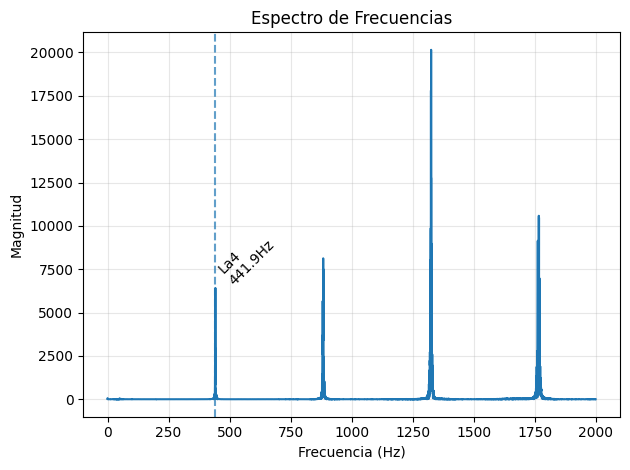

Instrumento: Oboe

--- NOTA ESPERADA ---
Nota completa: La4
Nota: La
Octava: 4

--- NOTA DETECTADA ---
Nota completa: La4
Nota: La
Octava: 4
Frecuencia fundamental: 441.93 Hz

--- VERIFICACIÓN ---
Nota correcta: True
Octava correcta: True
Ambas correctas: True

--- OTRAS FRECUENCIAS DETECTADAS ---
1. La4: 441.93 Hz (magnitud: 6417)


In [16]:
identifier = SingleNoteIdentifier()

print("=== IDENTIFICADOR DE NOTAS MUSICALES ===\n")
audio_file = "data/E1/TinySOL/Winds/Oboe/ordinario/Ob-ord-A4-ff-N-N.wav"

if os.path.exists(audio_file):
    print(f"Analizando: {audio_file}\n")

    filename = os.path.basename(audio_file)
    expected_note_octave, expected_note, expected_octave = identifier.extract_expected_note(filename)
    instrument = identifier.extract_instrument(audio_file)

    note, freq, all_notes = identifier.identify_note(audio_file, visualize=True)

    print(f"Instrumento: {instrument}\n")
    if expected_note_octave:
        print(f"--- NOTA ESPERADA ---")
        print(f"Nota completa: {expected_note_octave}")
        print(f"Nota: {expected_note}")
        print(f"Octava: {expected_octave}\n")

    if note:
        note_name = note[:-1]
        octave = note[-1]
        print(f"--- NOTA DETECTADA ---")
        print(f"Nota completa: {note}")
        print(f"Nota: {note_name}")
        print(f"Octava: {octave}")
        print(f"Frecuencia fundamental: {freq:.2f} Hz\n")

        if expected_note_octave:
            note_correct = (note_name == expected_note)
            octave_correct = (octave == expected_octave)
            both_correct = note_correct and octave_correct

            print(f"--- VERIFICACIÓN ---")
            print(f"Nota correcta: {note_correct}")
            print(f"Octava correcta: {octave_correct}")
            print(f"Ambas correctas: {both_correct}\n")

            if not octave_correct:
                diff = int(octave) - int(expected_octave)
                print(f"Diferencia de octava: {abs(diff)} octava(s)\n")

        print(f"--- OTRAS FRECUENCIAS DETECTADAS ---")
        for i, (n, f, m) in enumerate(all_notes[:5], 1):
            print(f"{i}. {n}: {f:.2f} Hz (magnitud: {m:.0f})")
else:
    print(f"El archivo no existe: {audio_file}")


In [17]:
note_identifier = SingleNoteIdentifier()
results = note_identifier.batch_process_directory("data/E1/TinySOL")
note_identifier.evaluate_accuracy(results)



=== ESTADÍSTICAS DE PRECISIÓN ===
Total de archivos procesados: 1197
Archivos con nota esperada identificable: 1197
Notas detectadas: 1197/1197 (100.00%)

--- PRECISIÓN ---
Nota correcta (sin octava): 1187/1197 (99.16%)
Octava correcta: 1179/1197 (98.50%)
Nota + Octava correctas: 1179/1197 (98.50%)

--- ERRORES DE NOTA (10) ---
  Tbn-ord-A#1-ff-N-T14d.wav: Esperada=La# | Detectada=Fa
  Acc-ord-A#7-pp-N-N.wav: Esperada=La# | Detectada=Sol
  Acc-ord-A4-pp-alt1-N.wav: Esperada=La | Detectada=Sol
  Acc-ord-A4-pp-N-N.wav: Esperada=La | Detectada=Sol
  Acc-ord-B3-pp-N-N.wav: Esperada=Si | Detectada=Sol
  Acc-ord-C#6-pp-N-N.wav: Esperada=Do# | Detectada=La#
  Acc-ord-D3-pp-N-N.wav: Esperada=Re | Detectada=Sol
  Acc-ord-D5-pp-alt1-N.wav: Esperada=Re | Detectada=Sol
  Acc-ord-E6-pp-alt2-N.wav: Esperada=Mi | Detectada=Sol
  Acc-ord-F#5-pp-alt2-N.wav: Esperada=Fa# | Detectada=Sol

--- ERRORES DE OCTAVA (18) ---
  Tbn-ord-A#1-ff-N-T14d.wav: Esperada=1 | Detectada=3
  Acc-ord-A#7-pp-N-N.wav: Esper